In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import astropy.coordinates as coord
import astropy.units as u
from IPython.display import Image

# Replication of Fig. 4 from van der Burg et al. (2020)
The top left panel of it

From Greg
In van der Burg, Rudnick et al (2020) I want you to reproduce the top left panel of Figure 4.  You will need to:
1. plot the Schechter function fits using the parameters for the R<1000 kpc sample in Table 4 and 
2. overplot the data for the Cluster <1000kpc sample from Table 3, including the uncertainties on the data points.

Show me #1 before you start #2.

The paper measures the stellar mass functions (SMF) of star-forming and quiescent galaxies in galaxy clusters at 1.0 < z < 1.4 with the goal of studying what drives quenching at z >= 1. The amount of quiescent galaxies in a population depends on stellar mass and environment. 

This Jupyter notebook includes notes of my thought process and information gathering. Because of this, some of the notes may be elementary, approximations, or possibly incorrect or outdated. 

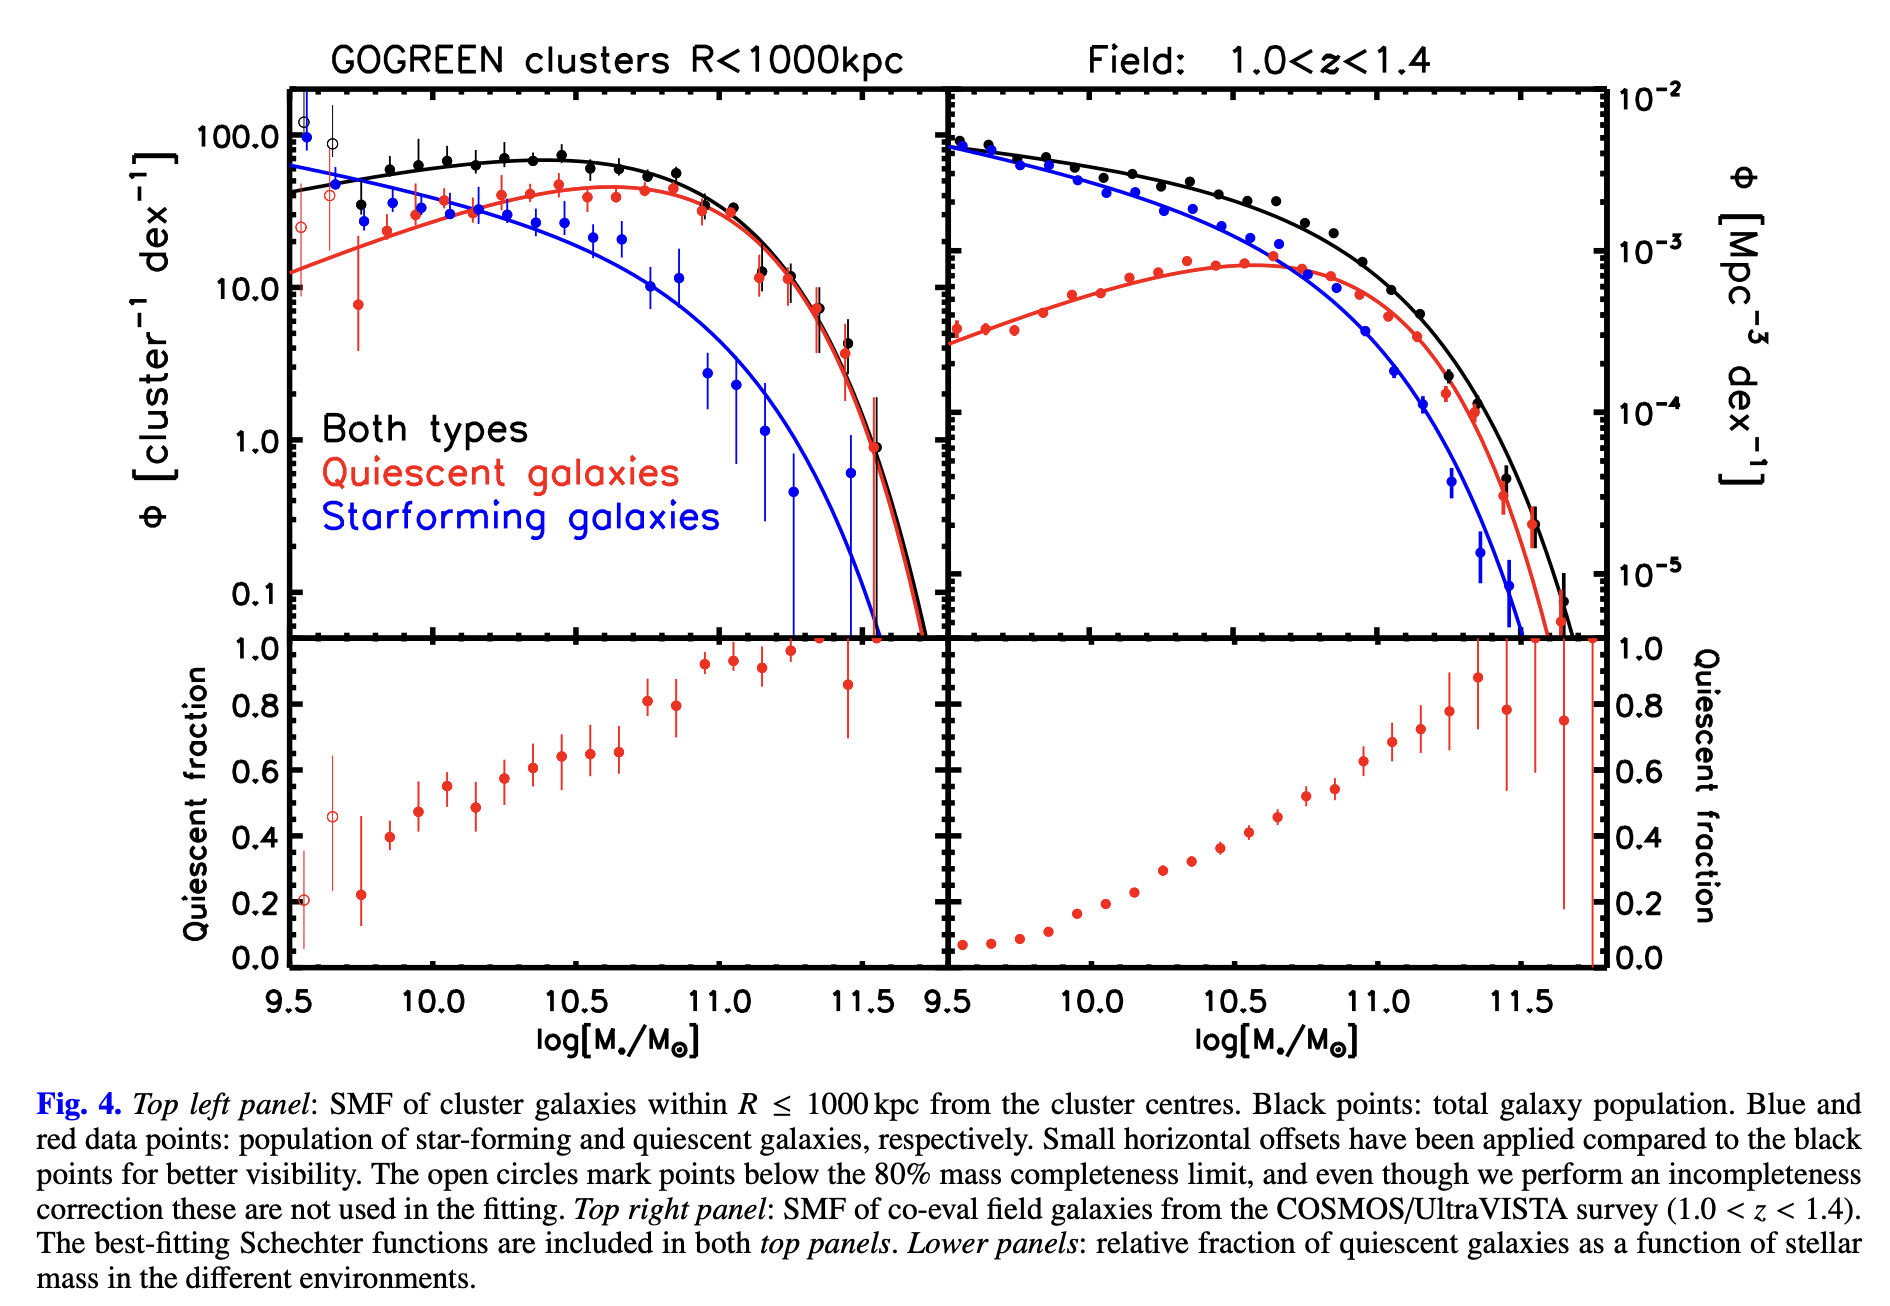

In [6]:
Image(filename='vanderBurgetal2020Fig4.png') 

## What I am making:

From the caption of Fig. 4:
"Top left panel: SMF of cluster galaxies within R ≤ 1000 kpc from the cluster centres. Black points: total galaxy population. Blue and
red data points: population of star-forming and quiescent galaxies, respectively. Small horizontal offsets have been applied compared to the black
points for better visibility. The open circles mark points below the 80% mass completeness limit, and even though we perform an incompleteness
correction these are not used in the fitting."

- Stellar Mass Function (SMF) of cluster galaxies over stellar mass with a fitting to the data.

## What I need:
1. SMF of cluster galaxies
    - The galaxy stellar mass function (SMF) is defined as the number density of galaxies Φ(M,z) in bins of stellar mass ∆M at
each redshift z, and is a fundamental cosmological observable in
the study of the statistical properties of galaxies (Weaver et al., 2023). 
2. The stellar mass of the cluster galaxies
3. A fitting parameterized by the Schechter function
    - The reference given in the paper is Schechter (1976)

# 1. plot the Schechter function fits using the parameters for the R<1000 kpc sample in Table 4

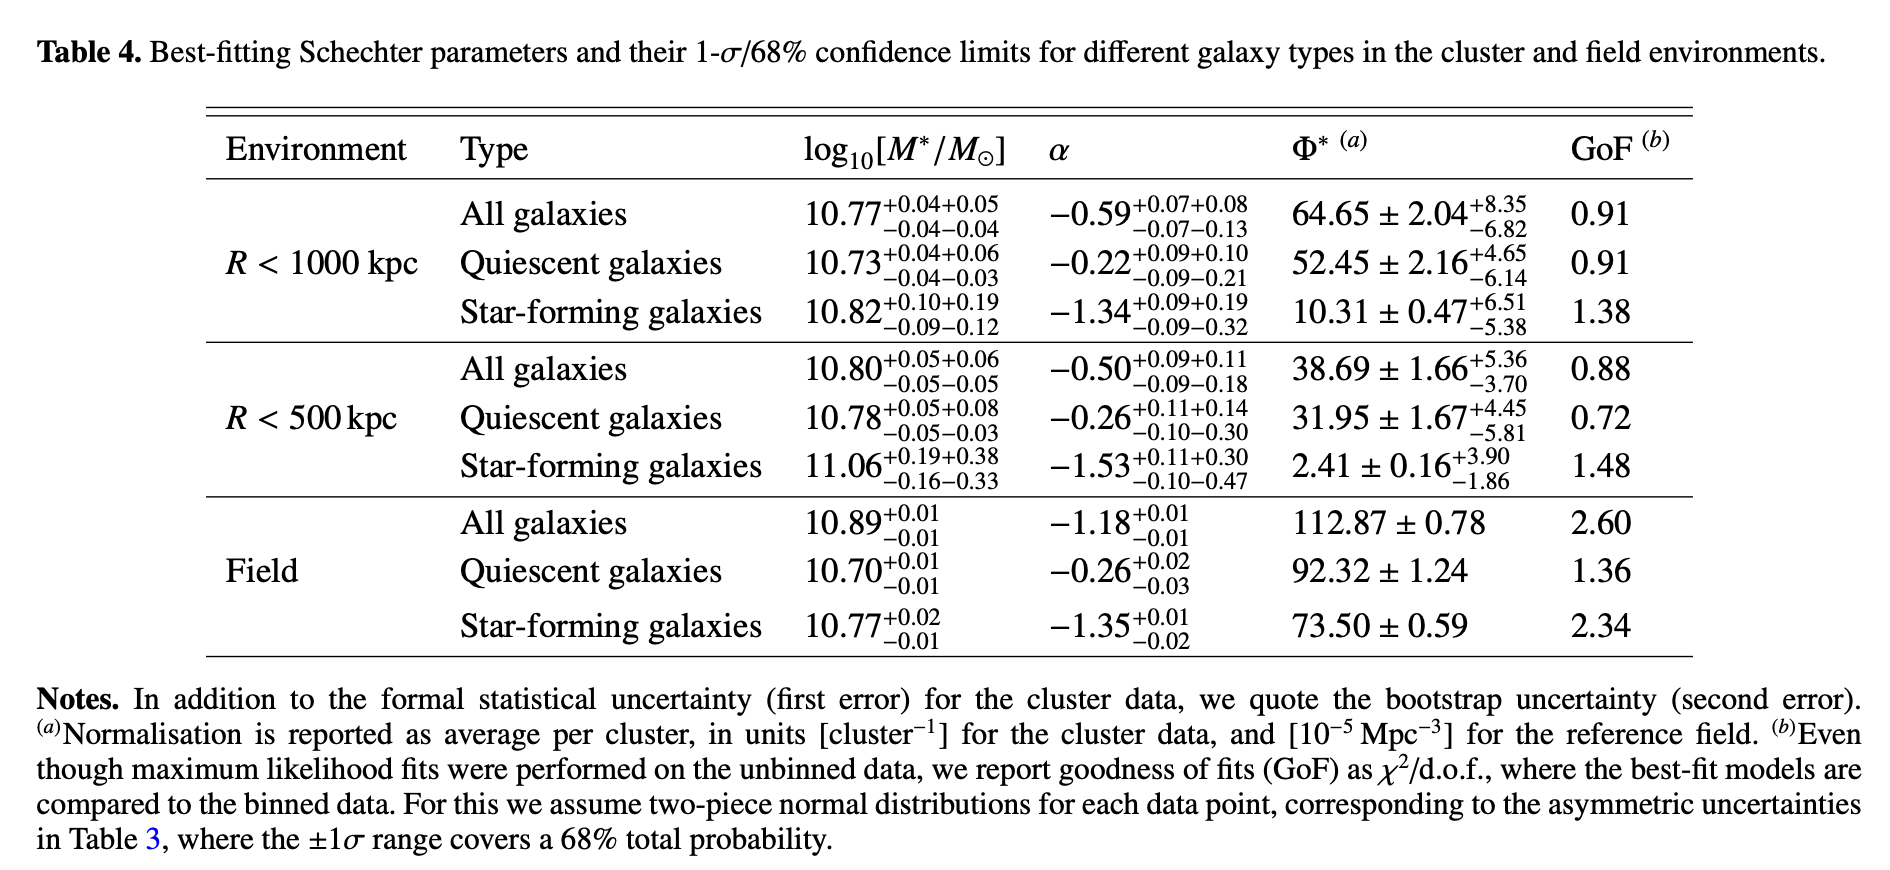

In [8]:
Image(filename='vanderBurgetal2020Table4.png')

## Schechter function
Just so I know what I am looking at,
#### Brief overview from Wikipedia of the seemingly related Schechter Luminosity Function:

The Schechter luminosity function 
$ϕ$ provides an approximation of the abundance of galaxies in a luminosity interval 
$L+dL$. The luminosity function has units of a number density 
$n$ per unit luminosity and is given by a power law with an exponential cut-off at high luminosity


$dn(L)=\phi ~dL=\phi ^{*}\left({\frac {L}{L^{*}}}\right)^{\alpha }\mathrm {e} ^{-L/L^{*}}d\left({\frac {L}{L^{*}}}\right)$

where
$L^{∗}$ is a characteristic galaxy luminosity controlling the cut-off, and the normalization $\phi ^{*}$ has units of number density.

In the Schechter function in van der Burg et al. (2020), luminosity is replaced with mass (this will still work since mass and luminosity are related).

#### In the paper, the Stellar Mass Function is modeled by fitting a Schechter function to the data. 

$\Phi (M) = \ln{(10)} \Phi^{*} [\frac{M}{M^{*}}]^{1 + \alpha} \exp{[- \frac{M}{M^{*}}]}$

where $M^{*}$ is characteristic mass, $\alpha$ the low-mass slope, and $\Phi^{*}$ the normalization. This is Eq. 9 in the paper.

Based on comparisons to the Schechter luminosity function, in this case, $\Phi(M)$ is the approximation of the abundance of galaxies in mass interval $M + dM$; parameters $M^{*}$, $\alpha$, and $\Phi^{*}$ are observationally dependent, which handles different z-values. Because of this, the Schechter function can be used to model the SMF.
 - $M^{*}$ depends on

## Constructing the Schecher Function of the Data

In [13]:
# Function for the Schechter function. 
def Schechter_Function(mass, char_mass, lowmass_slope, normalization):
    return math.log(10, math.e) * normalization ** (1 + lowmass_slope) * math.exp(-mass/char_mass)
# mass, char_mass, lowmass_slope, and normalization are float values.
# Notice that the figure values' units are dex^-1; you do not need to account for logs.

$R < 1000$ kpc. The considered mass range is $M < 10^{9.5} M_{\odot}$. 

In [ ]:
# Plotting the Schechter function for R < 1000 kpc
# Considers all
# All
# Quiescent
# Star-forming